# 03. What the measurements can and cannot see

Run `make all` first. This notebook reads `results/`.

Three questions in order: which parameters move which measurements (sensitivity), which
combinations are invisible (identifiability), and whether a maneuver fixes it (tie-breaker).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hcmtwin.analysis.identifiability import HIDDEN_ORDER
from hcmtwin.viz import style

style.apply()
pd.set_option("display.width", 200)
RESULTS = Path("../results")

## 1. Sensitivity

The first result is visible without any inference at all: the parameter that most
determines the outcome does not move any baseline measurement.

In [2]:
sobol = pd.read_csv(RESULTS / "sensitivity_sobol.csv")
outcome = (sobol[sobol["quantity"] == "ef_drop_at_mid_dose"]
           .sort_values("ST", ascending=False))
display(outcome[["parameter", "group", "S1", "ST"]].head(8).round(3))
display(pd.read_csv(RESULTS / "sensitivity_summary.csv").round(3))

,parameter,group,S1,ST
205,clearance_l_per_h,hidden,0.423,0.505
201,phi_baseline,hidden,0.181,0.220
198,wall_volume_ml,measured,0.037,0.112
204,ca50_ref_um,hidden,0.062,0.100
199,ref_cavity_volume_ml,measured,0.020,0.082
202,a_pas_kpa,hidden,0.040,0.067
203,b_pas,hidden,0.022,0.060
208,systemic_resistance_mmhg_s_per_ml,loading,0.003,0.011


,parameter,best_observable,best_total_order,best_routine_observable,best_routine_total_order,n_observables_above_0.05,visible
0,a_pas_kpa,atp_cost_per_stroke_work,0.436,cardiac_output_l_per_min,0.391,13,True
1,b_pas,atp_cost_per_stroke_work,0.389,e_over_e_prime,0.307,13,True
2,ca50_ref_um,atp_cost_per_stroke_work,0.181,esv_ml,0.125,6,True
3,phi_baseline,esv_ml,0.063,esv_ml,0.063,3,True
4,clearance_l_per_h,edv_ml,0.000,edv_ml,0.000,0,False


## 2. Identifiability

In [3]:
fisher = pd.read_csv(RESULTS / "fisher_table.csv")
realistic = fisher[fisher["noise_level"] == "realistic"]
eigen = [c for c in realistic.columns if c.startswith("eigenvalue_")]
print("median Fisher eigenvalue spectrum (largest first):")
print(realistic[eigen].median().round(6).to_string())
print()
weights = [c for c in realistic.columns if c.startswith("invisible_weight_")]
composition = realistic[weights].median()
composition.index = [c.replace("invisible_weight_", "") for c in composition.index]
print("composition of the least-visible direction:")
print(composition.round(4).to_string())

median Fisher eigenvalue spectrum (largest first):
eigenvalue_0    188.487911
eigenvalue_1     35.621641
eigenvalue_2      0.615710
eigenvalue_3      0.093405
eigenvalue_4      0.000000

composition of the least-visible direction:
phi_baseline         0.0
a_pas_kpa            0.0
b_pas                0.0
ca50_ref_um          0.0
clearance_l_per_h    1.0


In [4]:
confounding = pd.read_csv(RESULTS / "confounding_table.csv")
display(confounding[confounding["noise_level"] == "realistic"]
        [["parameter_a", "parameter_b", "median_abs_correlation",
          "fraction_above_threshold", "confounded"]].round(3))
display(pd.read_csv(RESULTS / "recovery_summary.csv").round(3))

,parameter_a,parameter_b,median_abs_correlation,fraction_above_threshold,confounded
10,a_pas_kpa,b_pas,0.676,0.30,False
11,phi_baseline,ca50_ref_um,0.469,0.02,False
12,a_pas_kpa,ca50_ref_um,0.119,0.00,False
13,phi_baseline,a_pas_kpa,0.082,0.00,False
14,phi_baseline,b_pas,0.069,0.00,False
15,b_pas,ca50_ref_um,0.055,0.00,False
16,b_pas,clearance_l_per_h,0.027,0.00,False
17,phi_baseline,clearance_l_per_h,0.025,0.00,False
18,a_pas_kpa,clearance_l_per_h,0.025,0.00,False
19,ca50_ref_um,clearance_l_per_h,0.016,0.00,False


,noise_level,parameter,median_ci90_width,median_abs_bias,n,recoverable
0,optimistic,ca50_ref_um,0.282,0.045,50,True
1,optimistic,phi_baseline,0.513,0.086,50,True
2,optimistic,b_pas,0.676,0.135,50,False
3,optimistic,a_pas_kpa,0.997,0.240,50,False
4,optimistic,clearance_l_per_h,1.423,0.338,50,False
5,realistic,ca50_ref_um,0.343,0.061,50,True
6,realistic,phi_baseline,0.548,0.092,50,True
7,realistic,b_pas,0.714,0.160,50,False
8,realistic,a_pas_kpa,1.005,0.215,50,False
9,realistic,clearance_l_per_h,1.444,0.346,50,False


### How well is each parameter recovered, patient by patient?

A relative credible-interval width near 2 means the interval spans the prior box: the data
said nothing at all about that parameter.

/var/folders/10/6q8bbnv13c1g30gp6l126shm0000gn/T/ipykernel_80407/1779066877.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  parts = ax.boxplot(data, vert=False, patch_artist=True, widths=0.55,


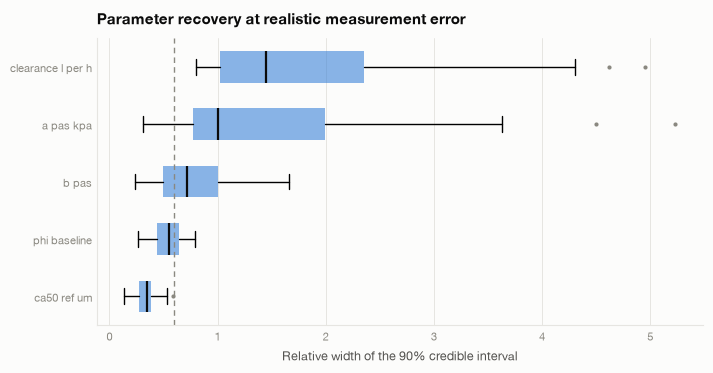

In [5]:
recovery = pd.read_csv(RESULTS / "recovery_table.csv")
realistic = recovery[recovery["noise_level"] == "realistic"]
order = (realistic.groupby("parameter")["relative_ci90_width"].median()
         .sort_values().index.tolist())
figure, ax = plt.subplots(figsize=(7.2, 3.8))
data = [realistic[realistic["parameter"] == p]["relative_ci90_width"].to_numpy()
        for p in order]
parts = ax.boxplot(data, vert=False, patch_artist=True, widths=0.55,
                   medianprops={"color": style.TEXT_PRIMARY, "linewidth": 1.6},
                   flierprops={"markersize": 3, "markerfacecolor": style.TEXT_MUTED,
                               "markeredgewidth": 0})
for patch in parts["boxes"]:
    patch.set_facecolor(style.SERIES[0]); patch.set_alpha(0.55); patch.set_linewidth(0)
ax.axvline(0.60, color=style.TEXT_MUTED, linestyle=(0, (4, 3)), linewidth=1.0)
ax.set_yticklabels([p.replace("_", " ") for p in order])
ax.set_xlabel("Relative width of the 90% credible interval")
ax.set_title("Parameter recovery at realistic measurement error")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 3. Tie-breaker

In [6]:
table = pd.read_csv(RESULTS / "tiebreaker_table.csv")
display(table)
detail = pd.read_csv(RESULTS / "tiebreaker_detail.csv")
display(detail[detail["usable"]].groupby(["pair", "maneuver"])
        [["correlation_before", "correlation_after", "best_signal_to_noise"]]
        .median().round(3))

,confounded_pair,best_maneuver,correlation_before,correlation_after,correlation_drop,ridge_width_before,ridge_width_after,ridge_shrinkage,ci_shrinkage_a,ci_shrinkage_b,discriminating_observable,expected_signal,signal_units,signal_to_noise,exceeds_measurement_noise,maneuver_usable_fraction,patients_agreeing_on_observable,n_patients
0,phi_baseline / ca50_ref_um,exercise,0.469,0.719,-0.281,0.1775,0.1610,0.054,0.026,0.425,peak_strain_amplitude,0.0049,dimensionless,2.19,True,1.0,0.58,50
1,a_pas_kpa / ca50_ref_um,exercise,0.119,0.106,0.006,0.3524,0.3641,0.046,0.043,0.425,peak_strain_amplitude,0.0117,dimensionless,8.63,True,1.0,0.50,50
2,a_pas_kpa / b_pas,tachycardia,0.676,0.847,-0.099,0.4074,0.4149,-0.021,0.057,0.020,peak_strain_amplitude,0.0040,dimensionless,0.96,False,1.0,0.46,50


correlation_before  correlation_after  best_signal_to_noise
pair                       maneuver                                                                       
a_pas_kpa / b_pas          afterload_increase               0.676              0.789                 0.464
                           exercise                         0.676              0.879                 0.510
                           preload_reduction                0.676              0.798                 0.311
                           tachycardia                      0.676              0.847                 0.417
a_pas_kpa / ca50_ref_um    afterload_increase               0.119              0.147                 1.408
                           exercise                         0.119              0.106                 2.635
                           preload_reduction                0.119              0.181                 1.201
                           tachycardia                      0.119              0.117                 1.785
phi_baseline / ca50_ref_um afterload_increase               0.469              0.662                 0.505
                           exercise                         0.469              0.719                 1.176
                           preload_reduction                0.469              0.631                 0.473
                           tachycardia                      0.469              0.686                 0.836

### The parameters no maneuver can help with

The distinction between *weakly identified* (a better measurement could help) and
*structurally unidentified* (there is no signal to amplify) is the most useful thing this
analysis produces, because the two call for completely different responses.

In [7]:
display(pd.read_csv(RESULTS / "structural_identifiability.csv").round(4))

,parameter,mean_invisible_weight,max_total_order_on_observables,total_order_on_outcome,structurally_invisible_at_baseline,matters_for_outcome,remedy
0,clearance_l_per_h,1.0,0.0000,0.5049,True,True,no pre-treatment maneuver can help; needs geno...
1,phi_baseline,0.0,0.0634,0.2202,False,True,"weakly identified; a maneuver may help, see th..."
2,ca50_ref_um,0.0,0.1810,0.0999,False,False,does not drive the outcome
3,a_pas_kpa,0.0,0.4359,0.0667,False,False,does not drive the outcome
4,b_pas,0.0,0.3889,0.0600,False,False,does not drive the outcome
